# Exploratory Data Analysis of Kilter database

## Setup
Import key libraries and open a connection to the Kilter SQLite database.

In [82]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
conn = sqlite3.connect('../data/raw/kilter_database.sqlite')
cursor = conn.cursor()

## Database Overview
* Display tables and row counts
* Get schema info for key tables
* Get core statistics from key tables

In [83]:
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('shared_syncs',), ('products',), ('product_sizes',), ('holes',), ('leds',), ('products_angles',), ('layouts',), ('sets',), ('product_sizes_layouts_sets',), ('placement_roles',), ('users',), ('user_permissions',), ('user_syncs',), ('walls_sets',), ('climb_cache_fields',), ('attempts',), ('difficulty_grades',), ('climb_stats',), ('tags',), ('android_metadata',), ('circuits',), ('circuits_climbs',), ('kits',), ('climb_random_positions',), ('beta_links',), ('bids',), ('climbs',), ('placements',), ('walls',), ('ascents',), ('sqlite_stat1',)]


In [84]:
# Get row counts for each table
table_info = []
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = [table[0] for table in cursor.fetchall()]

for table in tables:
    cursor.execute(f"SELECT COUNT(*) FROM {table};")
    row_count = cursor.fetchone()[0]
    table_info.append({'Table': table, 'Row Count': row_count})

table_stats = pd.DataFrame(table_info).sort_values('Row Count', ascending=False)
empty_tables = table_stats.loc[table_stats['Row Count'] == 0]
print(f"\nTotal Tables: {len(tables)}")
print(f"\nEmpty Tables:\n{empty_tables['Table'].tolist()}")
print(f"\nTable Statistics:\n{table_stats.drop(empty_tables.index).to_string(index=False)}")



Total Tables: 31

Empty Tables:
['ascents', 'walls', 'bids', 'walls_sets', 'climb_random_positions', 'circuits_climbs', 'circuits', 'tags', 'user_permissions', 'user_syncs', 'users']

Table Statistics:
                     Table  Row Count
               climb_stats     348028
                    climbs     344504
        climb_cache_fields     208457
                beta_links      32139
                      leds       7828
                placements       3773
                     holes       3294
                      kits        100
           products_angles         56
product_sizes_layouts_sets         41
         difficulty_grades         39
                  attempts         38
           placement_roles         30
              sqlite_stat1         24
             product_sizes         22
              shared_syncs         17
                      sets         11
                   layouts          8
                  products          7
          android_metadata          1

In [85]:
# Organize tables by category
table_categories = {
    'User Management': ['users', 'user_permissions', 'user_syncs'],
    'Climbs & Routes': ['climbs', 'climb_stats', 'climb_cache_fields', 'climb_random_positions', 'difficulty_grades', 'tags', 'beta_links'],
    'Attempts & Ascents': ['attempts', 'ascents', 'bids'],
    'Board Hardware': ['walls', 'products', 'product_sizes', 'holes', 'leds', 'products_angles', 'layouts', 'sets', 'placements', 'kits', 'product_sizes_layouts_sets', 'placement_roles', 'walls_sets'],
    'Circuits': ['circuits', 'circuits_climbs'],
    'Synchronization': ['shared_syncs', 'android_metadata'],
    'System': ['sqlite_stat1']
}

print("\n" + "="*60)
print("TABLE ORGANIZATION BY CATEGORY")
print("="*60)

for category, table_list in table_categories.items():
    existing_tables = [t for t in table_list if t in tables]
    if existing_tables:
        print(f"\n{category}:")
        for table in existing_tables:
            cursor.execute(f"SELECT COUNT(*) FROM {table};")
            count = cursor.fetchone()[0]
            print(f"  • {table}: {count:,} rows")



TABLE ORGANIZATION BY CATEGORY

User Management:
  • users: 0 rows
  • user_permissions: 0 rows
  • user_syncs: 0 rows

Climbs & Routes:
  • climbs: 344,504 rows
  • climb_stats: 348,028 rows
  • climb_cache_fields: 208,457 rows
  • climb_random_positions: 0 rows
  • difficulty_grades: 39 rows
  • tags: 0 rows
  • beta_links: 32,139 rows

Attempts & Ascents:
  • attempts: 38 rows
  • ascents: 0 rows
  • bids: 0 rows

Board Hardware:
  • walls: 0 rows
  • products: 7 rows
  • product_sizes: 22 rows
  • holes: 3,294 rows
  • leds: 7,828 rows
  • products_angles: 56 rows
  • layouts: 8 rows
  • sets: 11 rows
  • placements: 3,773 rows
  • kits: 100 rows
  • product_sizes_layouts_sets: 41 rows
  • placement_roles: 30 rows
  • walls_sets: 0 rows

Circuits:
  • circuits: 0 rows
  • circuits_climbs: 0 rows

Synchronization:
  • shared_syncs: 17 rows
  • android_metadata: 1 rows

System:
  • sqlite_stat1: 24 rows


In [86]:
# Get schema information for key tables
def get_table_schema(table_name):
    cursor.execute(f"PRAGMA table_info({table_name});")
    columns = cursor.fetchall()
    return columns

# Display schema for key tables
key_tables = ['climb_stats', 'climbs', 'climb_cache_fields', 'ascents', 'users', 'walls', 'attempts']
for table in key_tables:
    if table in tables:
        print(f"\n{table.upper()} Schema:")
        schema = get_table_schema(table)
        for col in schema:
            print(f"  {col[1]} ({col[2]})")



CLIMB_STATS Schema:
  climb_uuid (TEXT)
  angle (INT UNSIGNED)
  display_difficulty (FLOAT UNSIGNED)
  benchmark_difficulty (FLOAT UNSIGNED)
  ascensionist_count (INT UNSIGNED)
  difficulty_average (FLOAT UNSIGNED)
  quality_average (FLOAT UNSIGNED)
  fa_username (TEXT)
  fa_at (TEXT)

CLIMBS Schema:
  uuid (TEXT)
  layout_id (INT UNSIGNED)
  setter_id (INT UNSIGNED)
  setter_username (TEXT)
  name (TEXT)
  description (TEXT)
  hsm (INT UNSIGNED)
  edge_left (INT UNSIGNED)
  edge_right (INT UNSIGNED)
  edge_bottom (INT UNSIGNED)
  edge_top (INT UNSIGNED)
  angle (INT)
  frames_count (INT UNSIGNED)
  frames_pace (INT UNSIGNED)
  frames (TEXT)
  is_draft (BOOLEAN)
  is_listed (BOOLEAN)
  created_at (TEXT)
  is_nomatch (BOOLEAN)

CLIMB_CACHE_FIELDS Schema:
  climb_uuid (TEXT)
  ascensionist_count (INT UNSIGNED)
  display_difficulty (FLOAT UNSIGNED)
  quality_average (FLOAT UNSIGNED)

ASCENTS Schema:
  uuid (TEXT)
  climb_uuid (TEXT)
  angle (INT UNSIGNED)
  is_mirror (BOOLEAN)
  user_id 

## Climbs and Routes
* Check for NULL values
* Display sample data from major tables

### Climb data completeness
Check NULL values across climbs and related tables.

In [72]:
# Check NULL values in climbs and related tables
print("="*60)
print("NULL VALUES IN CLIMBS & ROUTES TABLES")
print("="*60)

climb_related_tables = ['climbs', 'climb_stats', 'climb_cache_fields', 'difficulty_grades', 'beta_links']

for table in climb_related_tables:
    if table in tables:
        print(f"\n{table.upper()}:")
        schema = get_table_schema(table)
        cursor.execute(f"SELECT COUNT(*) FROM {table};")
        total = cursor.fetchone()[0]
        
        if total == 0:
            print("  (empty table)")
            continue
            
        has_nulls = False
        for col in schema:
            col_name = col[1]
            cursor.execute(f"SELECT COUNT(*) FROM {table} WHERE {col_name} IS NULL;")
            null_count = cursor.fetchone()[0]
            if null_count > 0:
                pct = (null_count / total) * 100
                print(f"  {col_name}: {null_count} NULLs ({pct:.1f}%)")
                has_nulls = True
        
        if not has_nulls:
            print("  (no NULL values)")


NULL VALUES IN CLIMBS & ROUTES TABLES

CLIMBS:
  angle: 103574 NULLs (30.1%)

CLIMB_STATS:
  benchmark_difficulty: 347394 NULLs (99.8%)

CLIMB_CACHE_FIELDS:
  ascensionist_count: 567 NULLs (0.3%)
  display_difficulty: 567 NULLs (0.3%)
  quality_average: 567 NULLs (0.3%)

DIFFICULTY_GRADES:
  (no NULL values)

BETA_LINKS:
  foreign_username: 6580 NULLs (20.5%)
  angle: 15106 NULLs (47.0%)
  thumbnail: 1000 NULLs (3.1%)


### Sample rows
Preview the first few records from major climb tables.

In [73]:
# Display sample data from major climb tables
print("\n" + "="*60)
print("SAMPLE DATA FROM MAJOR TABLES")
print("="*60)

major_climb_tables = ['climbs', 'climb_stats', 'climb_cache_fields', 'difficulty_grades', 'beta_links']

for table in major_climb_tables:
    if table in tables:
        cursor.execute(f"SELECT COUNT(*) FROM {table};")
        count = cursor.fetchone()[0]
        
        if count == 0:
            print(f"\n{table.upper()}: (empty)")
            continue
        
        print(f"\n{table.upper()} (first 5 rows):")
        df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
        print(df.to_string(index=False))



SAMPLE DATA FROM MAJOR TABLES

CLIMBS (first 5 rows):
                            uuid  layout_id  setter_id     setter_username                          name                              description  hsm  edge_left  edge_right  edge_bottom  edge_top angle  frames_count  frames_pace                                                                                                                                                                                                                                                                                   frames  is_draft  is_listed                 created_at  is_nomatch
002047402B6941CEA5ED7BB09FBFE14D          1       1051        kilterjackie 4/26 Harder Than It Should Be                                             3         40         136            4       152  None             1            0                                                                                                 p1145r12p1146r12p1149r13p1186r13p1201r13p1256r15

### Join preview
Join climbs with climb_stats and display a sample of the merged data.

In [69]:
# Join climbs and climb_stats tables
print("\n" + "="*60)
print("CLIMBS + CLIMB_STATS JOIN")
print("="*60)

join_query = """
SELECT c.*, cs.*
FROM climbs c
LEFT JOIN climb_stats cs ON c.uuid = cs.climb_uuid
LIMIT 5
"""

df_joined = pd.read_sql_query(join_query, conn)
print(f"\nJoined table shape: {df_joined.shape}")
print(f"\nFirst 5 rows:")
print(df_joined.to_string())



CLIMBS + CLIMB_STATS JOIN

Joined table shape: (5, 28)

First 5 rows:
                               uuid  layout_id  setter_id      setter_username                           name                               description  hsm  edge_left  edge_right  edge_bottom  edge_top angle  frames_count  frames_pace                                                                                                                                                                                                                                                                                    frames  is_draft  is_listed                  created_at  is_nomatch                        climb_uuid  angle  display_difficulty benchmark_difficulty  ascensionist_count  difficulty_average  quality_average   fa_username                fa_at
0  002047402B6941CEA5ED7BB09FBFE14D          1       1051         kilterjackie  4/26 Harder Than It Should Be                                              3         40         

### Difficulty distribution
Histogram of rounded route difficulty


DIFFICULTY AVERAGE DISTRIBUTION

Total climbs with difficulty data: 348028

Difficulty distribution by grade:
 difficulty_rounded boulder_name  count
               10.0        4a/V0   5769
               11.0        4b/V0   6837
               12.0        4c/V0   6032
               13.0        5a/V1   9278
               14.0        5b/V1  11203
               15.0        5c/V2  19492
               16.0        6a/V3  23740
               17.0       6a+/V3  23814
               18.0        6b/V4  28305
               19.0       6b+/V4  27601
               20.0        6c/V5  31368
               21.0       6c+/V5  28480
               22.0        7a/V6  38414
               23.0       7a+/V7  32354
               24.0        7b/V8  19697
               25.0       7b+/V8  13282
               26.0        7c/V9  11064
               27.0      7c+/V10   6371
               28.0       8a/V11   3118
               29.0      8a+/V12   1105
               30.0       8b/V13    297
         

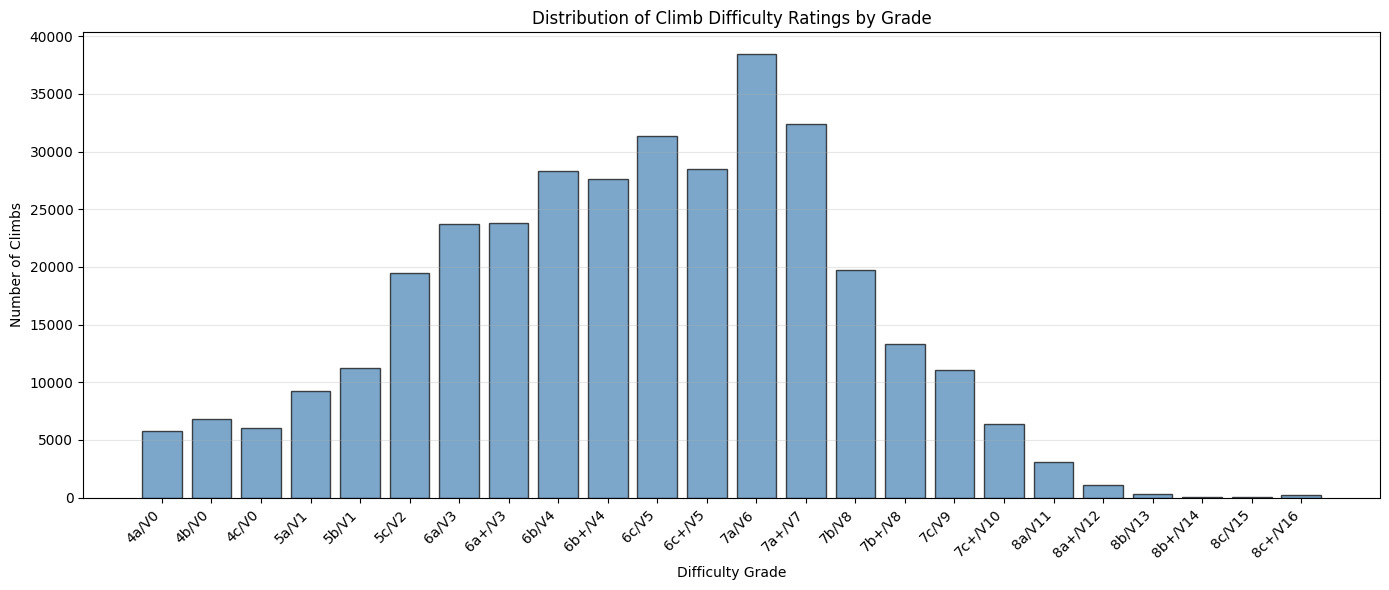

In [77]:
# Histogram of difficulty_average from climb_stats
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("DIFFICULTY AVERAGE DISTRIBUTION")
print("="*60)

# Round difficulty_average and join with difficulty_grades
difficulty_df = pd.read_sql_query("""
    SELECT 
        ROUND(cs.difficulty_average) as difficulty_rounded,
        dg.boulder_name,
        COUNT(*) as count
    FROM climb_stats cs
    LEFT JOIN difficulty_grades dg ON ROUND(cs.difficulty_average) = dg.difficulty
    WHERE cs.difficulty_average IS NOT NULL
    GROUP BY ROUND(cs.difficulty_average), dg.boulder_name
    ORDER BY difficulty_rounded
""", conn)

print(f"\nTotal climbs with difficulty data: {difficulty_df['count'].sum()}")
print(f"\nDifficulty distribution by grade:")
print(difficulty_df.to_string(index=False))

# Create histogram with boulder_name as x-axis labels
plt.figure(figsize=(14, 6))
plt.bar(range(len(difficulty_df)), difficulty_df['count'], edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Difficulty Grade')
plt.ylabel('Number of Climbs')
plt.title('Distribution of Climb Difficulty Ratings by Grade')
plt.xticks(range(len(difficulty_df)), difficulty_df['boulder_name'], rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


## Wall and Board Info

### Hardware data completeness
Check NULL values across board hardware tables.

In [78]:
# Check NULL values in board hardware tables
print("="*60)
print("NULL VALUES IN BOARD HARDWARE TABLES")
print("="*60)

board_hardware_tables = ['walls', 'products', 'product_sizes', 'holes', 'leds', 'products_angles', 'layouts', 'sets', 'placements', 'kits', 'product_sizes_layouts_sets', 'placement_roles', 'walls_sets']

for table in board_hardware_tables:
    if table in tables:
        print(f"\n{table.upper()}:")
        schema = get_table_schema(table)
        cursor.execute(f"SELECT COUNT(*) FROM {table};")
        total = cursor.fetchone()[0]
        
        if total == 0:
            print("  (empty table)")
            continue
        
        has_nulls = False
        for col in schema:
            col_name = col[1]
            cursor.execute(f"SELECT COUNT(*) FROM {table} WHERE {col_name} IS NULL;")
            null_count = cursor.fetchone()[0]
            if null_count > 0:
                pct = (null_count / total) * 100
                print(f"  {col_name}: {null_count} NULLs ({pct:.1f}%)")
                has_nulls = True
        
        if not has_nulls:
            print("  (no NULL values)")


NULL VALUES IN BOARD HARDWARE TABLES

WALLS:
  (empty table)

PRODUCTS:
  password: 7 NULLs (100.0%)

PRODUCT_SIZES:
  (no NULL values)

HOLES:
  (no NULL values)

LEDS:
  (no NULL values)

PRODUCTS_ANGLES:
  (no NULL values)

LAYOUTS:
  password: 2 NULLs (25.0%)

SETS:
  (no NULL values)

PLACEMENTS:
  default_placement_role_id: 1152 NULLs (30.5%)

KITS:
  (no NULL values)

PRODUCT_SIZES_LAYOUTS_SETS:
  (no NULL values)

PLACEMENT_ROLES:
  (no NULL values)

WALLS_SETS:
  (empty table)


### Hardware sample rows
Preview the first few records from major board hardware tables.

In [80]:
# Display sample data from board hardware tables
print("\n" + "="*60)
print("SAMPLE DATA FROM BOARD HARDWARE TABLES")
print("="*60)

major_board_tables = ['walls', 'products', 'product_sizes', 'holes', 'leds', 'products_angles', 'layouts', 'sets', 'placements', 'kits', 'product_sizes_layouts_sets', 'placement_roles', 'walls_sets']

for table in major_board_tables:
    if table in tables:
        cursor.execute(f"SELECT COUNT(*) FROM {table};")
        count = cursor.fetchone()[0]
        
        if count == 0:
            print(f"\n{table.upper()}: (empty)")
            continue
        
        print(f"\n{table.upper()} (first 5 rows):")
        df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 5", conn)
        print(df.to_string(index=False))



SAMPLE DATA FROM BOARD HARDWARE TABLES

WALLS: (empty)

PRODUCTS (first 5 rows):
 id                  name  is_listed password  min_count_in_frame  max_count_in_frame
  1 Kilter Board Original          1     None                   2                  35
  7 Kilter Board Homewall          1     None                   2                  35
  2                  JUUL          1     None                   2                  35
  3            Demo Board          0     None                   2                  35
  4             BKB Board          0     None                   2                  35

PRODUCT_SIZES (first 5 rows):
 id  product_id  edge_left  edge_right  edge_bottom  edge_top      name             description                   image_filename  position  is_listed
  8           1         24         120            0       156    8 x 12                    Home  product_sizes/8-transparent.png         1          1
 11           2          0         210            0       116 Full Wall